## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde

df = pd.read_csv("air_fryers_clean_brand_year.csv")

brand_name_map = {
    "chefman": "Chefman", "cosori": "Cosori", "cuisinart": "Cuisinart",
    "dash": "Dash", "gowise usa": "GoWISE USA", "instant_pot": "Instant Pot",
    "ninja": "Ninja", "nuwave": "NuWave", "oster": "Oster", "ultrean": "Ultrean"
}
df["brand_label"] = df["brand"].map(brand_name_map)
brands = sorted(df["brand_label"].unique())
palette = plt.cm.tab10.colors
brand_colors = {b: palette[i] for i, b in enumerate(brands)}

print("Data loaded:", df.shape)
display(df.head())

Data loaded: (50, 16)


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share,brand_label
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826,Chefman
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964,Cosori
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150,Cuisinart
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832,Dash
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364,GoWISE USA


In [4]:
df_og = df.drop(columns=["brand_label"])
df_og["log_share"] = np.log(df_og["brand_share"])
df_model = pd.get_dummies(df_og, columns=["brand", "year"], drop_first=True)

X_vars = [
    "avg_price", "avg_rating",
    "compact_share", "dual_basket_share", "oven_style_share",
    "rotisserie_share", "window_share"
]
for col in df_model.columns:
    if col.startswith("brand_") or col.startswith("year_"):
        X_vars.append(col)

model = LinearRegression().fit(df_model[X_vars], df_model["log_share"])
beta_price = model.coef_[0]

print(f"Estimated price coefficient (beta_price): {beta_price:.6f}")

Estimated price coefficient (beta_price): -0.026674


In [6]:
# compute demand_slop, unit_cost, markup, and average_profit

s = df["brand_share"].values
p = df["avg_price"].values

df["demand_slope"]   = beta_price * s * (1 - s)
df["unit_cost"]      = p + s / df["demand_slope"].values
df["markup"]         = p - df["unit_cost"].values
df["average_profit"] = s * df["markup"].values

display(
    df[["brand_label", "year", "avg_price", "demand_slope",
        "unit_cost", "markup", "average_profit"]].round(4)
)

,brand_label,year,avg_price,demand_slope,unit_cost,markup,average_profit
0,Chefman,2019,72.9637,-0.0019,32.3902,40.5735,3.0842
1,Cosori,2019,159.9900,-0.0000,122.4734,37.5166,0.0274
2,Cuisinart,2019,229.4653,-0.0026,187.4751,41.9902,4.5009
3,Dash,2019,55.1763,-0.0043,8.3311,46.8453,9.3560
4,GoWISE USA,2019,83.5756,-0.0055,30.6107,52.9649,15.4756
5,Instant Pot,2019,78.0199,-0.0004,39.9294,38.0906,0.6013
6,Ninja,2019,112.1584,-0.0041,65.7249,46.4335,8.9442
7,NuWave,2019,151.0999,-0.0008,112.3672,38.7327,1.2435
8,Oster,2019,191.9437,-0.0009,153.1525,38.7912,1.3020
9,Ultrean,2019,80.6247,-0.0013,41.1590,39.4657,1.9764


Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

### 1. What are the average unit costs and markups for each brand over the years?

Average Unit Costs and Markups by Brand:


,avg_price,avg_rating,unit_cost,markup,average_profit
brand_label,,,,,
Cuisinart,223.95,4.44,182.92,41.02,3.53
Oster,189.03,4.39,150.58,38.45,0.96
Ninja,145.34,4.74,98.95,46.39,8.91
NuWave,137.02,4.39,97.53,39.50,2.01
Cosori,114.27,4.66,74.75,39.52,2.03
Instant Pot,104.46,4.56,58.48,45.98,8.49
Chefman,90.94,4.43,49.47,41.47,3.98
GoWISE USA,87.45,4.58,43.46,43.99,6.50
Ultrean,78.11,4.67,36.70,41.42,3.93


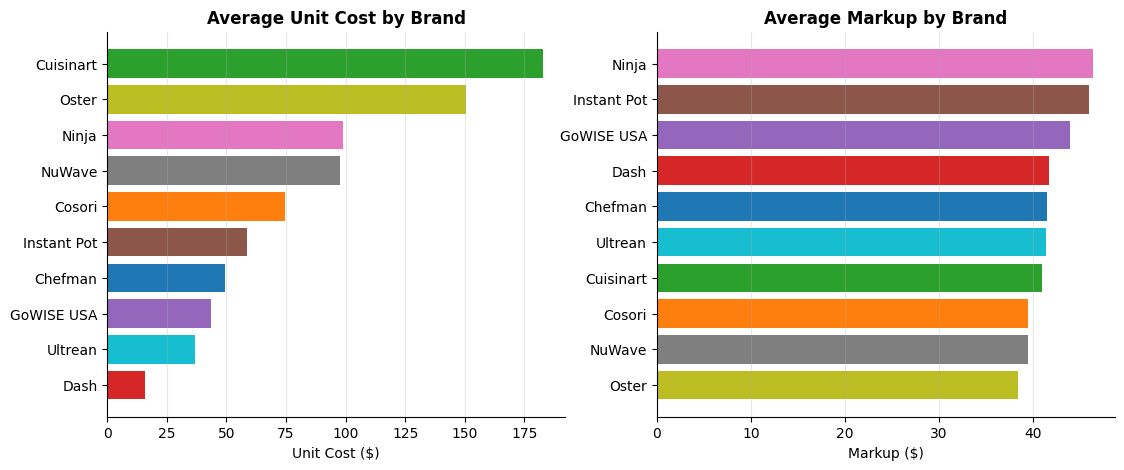

In [14]:
brand_avg = (
    df.groupby("brand_label")[["avg_price", "avg_rating", "unit_cost", "markup", "average_profit"]]
      .mean().sort_values("unit_cost", ascending=False).round(2)
)
print("Average Unit Costs and Markups by Brand:")
display(brand_avg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes,
                           ["unit_cost", "markup"],
                           ["Average Unit Cost by Brand", "Average Markup by Brand"]):
    ba = brand_avg.sort_values(col, ascending=False)
    ax.barh(ba.index, ba[col], color=[brand_colors[b] for b in ba.index])
    ax.set_xlabel(f"{col.replace('_', ' ').title()} ($)")
    ax.set_title(title, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

Unit costs vary substantially. `Cuisinart` ($182.92) and `Oster` ($150.58) have the highest average unit costs, reflecting their premium positioning. `Dash` ($15.76) and `Ultrean` ($36.70) sit at the lower end. Markups, however, are quite similar across brands, ranging roughly $38-$46. This means that the wide price differences in this market mostly reflect cost differences as opposed to differential pricing power.

### 2. Are any inferred unit costs negative? If so, what might that mean?

In [9]:
neg_costs = df[df["unit_cost"] < 0]
print(f"Number of negative unit costs: {len(neg_costs)}")
print(f"Min unit cost: ${df['unit_cost'].min():.2f}  |  Max: ${df['unit_cost'].max():.2f}")

Number of negative unit costs: 0
Min unit cost: $8.33  |  Max: $187.48


No negative unit costs found, which means that all 50 brand-year estimates are positive and economically plausible. This validates the internal consistency of the demand model.

### 3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?

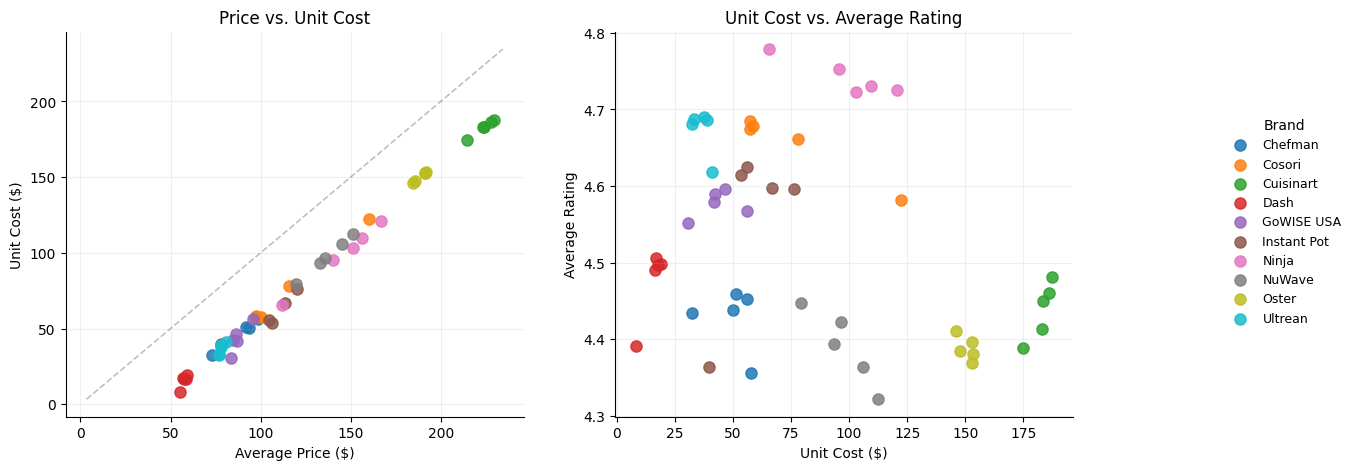

Top 3 brands by average unit cost:


,avg_price,unit_cost,avg_rating
brand_label,,,
Cuisinart,223.95,182.92,4.44
Oster,189.03,150.58,4.39
Ninja,145.34,98.95,4.74


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for brand in brands:
    bdf = df[df["brand_label"] == brand]
    kw = dict(label=brand, color=brand_colors[brand], s=65, alpha=0.85)
    axes[0].scatter(bdf["avg_price"], bdf["unit_cost"], **kw)
    axes[1].scatter(bdf["unit_cost"], bdf["avg_rating"], **kw)

lim = [df["unit_cost"].min() - 5, df["avg_price"].max() + 5]
axes[0].plot(lim, lim, "k--", alpha=0.25, lw=1.2)

for ax, xlabel, ylabel, title in zip(axes,
    ["Average Price ($)", "Unit Cost ($)"],
    ["Unit Cost ($)",     "Average Rating"],
    ["Price vs. Unit Cost", "Unit Cost vs. Average Rating"]):
    ax.set(xlabel=xlabel, ylabel=ylabel, title=title)
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

fig.legend(*axes[0].get_legend_handles_labels(), title="Brand",
           bbox_to_anchor=(1.01, 0.5), loc="center left", frameon=False, fontsize=9)
plt.show()

print("Top 3 brands by average unit cost:")
display(brand_avg[["avg_price", "unit_cost", "avg_rating"]].head(3))

`Cuisinart` and `Oster` have the highest unit costs and prices. The scatter of unit cost vs. average rating shows only a weak positive relationship. More expensive products are slightly better rated, but not dramatically so. Consumers do not receive proportionally higher quality for higher prices. Some of the premium reflects brand positioning rather than consumer-measurable quality.

### 4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.

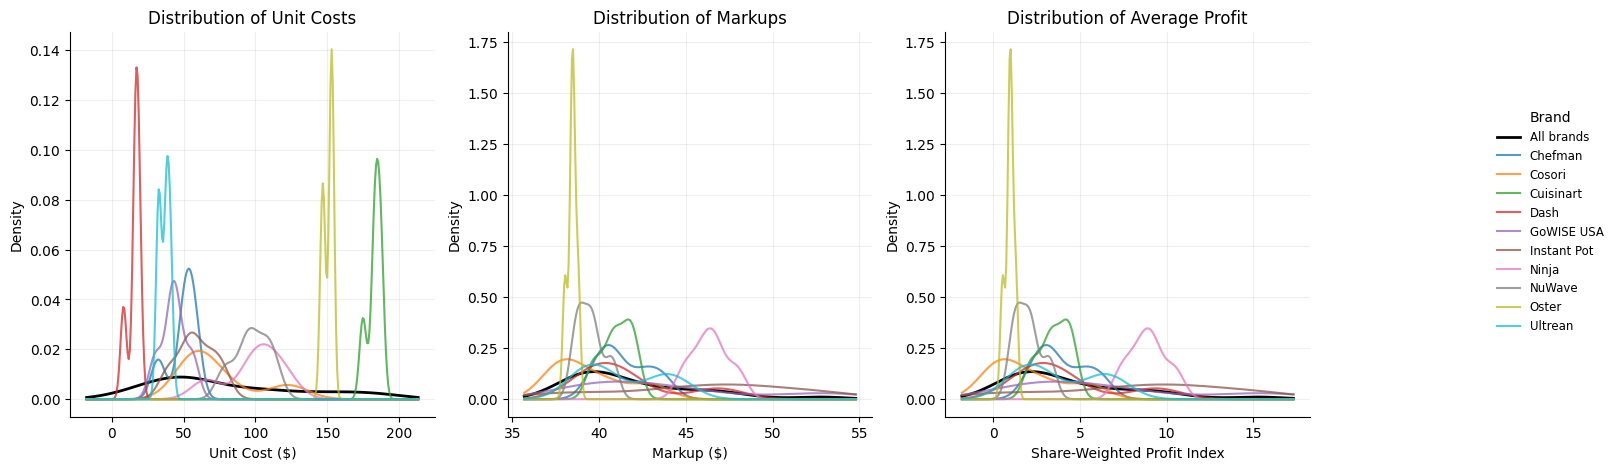

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_vars = [
    ("unit_cost",   "Unit Cost ($)",    "Distribution of Unit Costs"),
    ("markup",  "Markup ($)",   "Distribution of Markups"),
    ("average_profit",  "Share-Weighted Profit Index",  "Distribution of Average Profit"),
]

for ax, (var, xlabel, title) in zip(axes, plot_vars):
    vals = df[var].dropna().values
    x = np.linspace(vals.min() - vals.std()*0.5, vals.max() + vals.std()*0.5, 300)

    # overall density
    ax.plot(x, gaussian_kde(vals, bw_method=0.4)(x), color="black", lw=2, label="All brands")

    # per-brand density
    for brand in brands:
        bvals = df[df["brand_label"] == brand][var].dropna().values
        if len(bvals) >= 3:
            ax.plot(x, gaussian_kde(bvals, bw_method=0.5)(x),
                    color=brand_colors[brand], lw=1.5, alpha=0.75, label=brand)

    ax.set(xlabel=xlabel, ylabel="Density", title=title)
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

fig.legend(*axes[0].get_legend_handles_labels(), title="Brand",
           bbox_to_anchor=(1.01, 0.5), loc="center left", frameon=False, fontsize=8.5)
plt.show()

Unit cost distributions are right-skewed, driven by Cuisinart and Oster. Markups are tightly clustered, reinforcing that pricing power is broadly similar across the market. Average profit is concentrated at the top: `Ninja` stands out with a distribution spread furthest to the right. Most other brands cluster near zero, with `Instant Pot`'s distribution being narrow and low-variance rather than a true high-profit outlier.


### 5. Which brands have the highest share-weighted average profit?

Average Share-Weighted Profit by Brand (ranked):


,average_profit
brand_label,
Ninja,8.91
Instant Pot,8.49
GoWISE USA,6.50
Dash,4.23
Chefman,3.98
Ultrean,3.93
Cuisinart,3.53
Cosori,2.03
NuWave,2.01


C:\Users\emili\AppData\Local\Temp\ipykernel_40744\3684029140.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ba_p.index, rotation=30, ha="right")


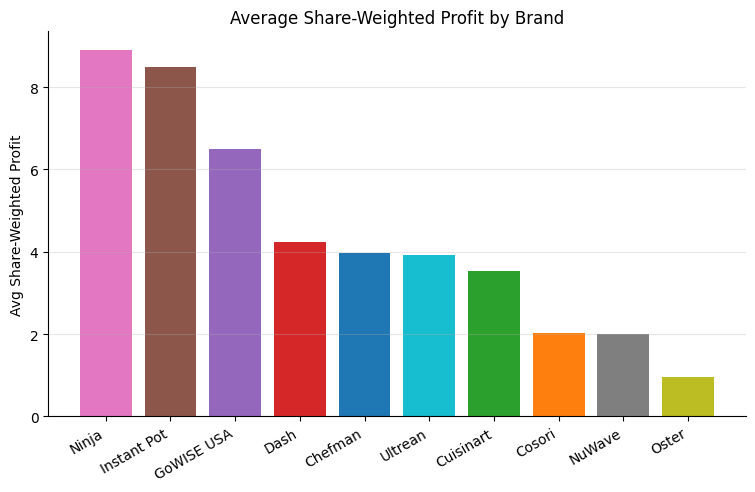

In [19]:
profit_rank = brand_avg["average_profit"].sort_values(ascending=False).round(4)
print("Average Share-Weighted Profit by Brand (ranked):")
display(profit_rank.to_frame())

ba_p = brand_avg.sort_values("average_profit", ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(ba_p.index, ba_p["average_profit"], color=[brand_colors[b] for b in ba_p.index])
ax.set(ylabel="Avg Share-Weighted Profit", title="Average Share-Weighted Profit by Brand")
ax.set_xticklabels(ba_p.index, rotation=30, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

`Ninja`(8.91) and `Instant Pot`(8.49) lead on average share-weighted profit, combining strong markups with large market shares. `GoWISE USA` (6.50) and `Dash` (4.23) follow. `Oster` (0.96) earns the lowest profit index despite high prices, because its share is small and declining.